In [6]:
!pip install textblob

In [9]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to C:\Users\Chandani
[nltk_data]     Sah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Chandani Sah\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.


True

💬 SENTIMENT ANALYSIS RESULTS
                                               Review  Polarity  Subjectivity  Sentiment
This product is absolutely amazing! Best purchase ...     0.875         0.600 Positive 😊
Terrible quality, broke after one day. Very disapp...    -0.988         0.988 Negative 😠
 It's okay, nothing special. Does the job I guess....     0.429         0.536 Positive 😊
Fantastic! Exceeded all my expectations. Highly re...     0.350         0.720 Positive 😊
Worst product I've ever bought. Complete waste of ...    -0.367         0.467 Negative 😠
       Pretty good for the price. Would buy again....     0.475         0.800 Positive 😊
Not what I expected. Color was different from the ...    -0.050         0.500  Neutral 😐
   Love it! Fast delivery and excellent packaging....     0.608         0.733 Positive 😊
Average product. Nothing outstanding but works fin...     0.256         0.592 Positive 😊
Absolutely horrible experience. Customer service w...    -0.650         0.800 Neg

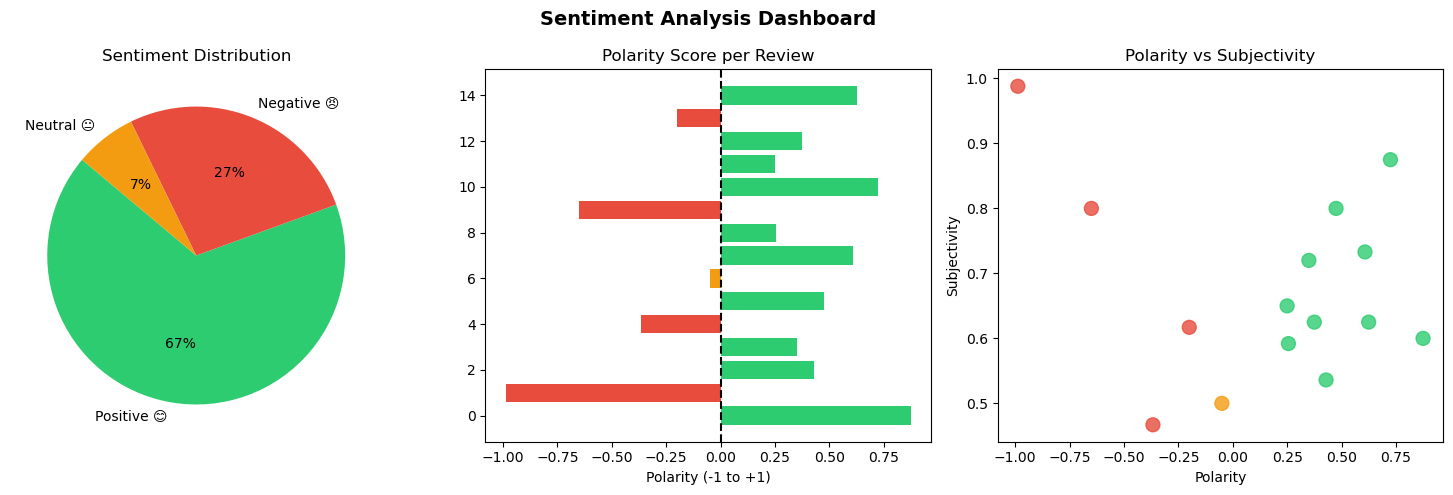


✅ Sentiment dashboard saved!


In [15]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
from collections import Counter
import re

reviews = [
    "This product is absolutely amazing! Best purchase ever.",
    "Terrible quality, broke after one day. Very disappointed.",
    "It's okay, nothing special. Does the job I guess.",
    "Fantastic! Exceeded all my expectations. Highly recommend!",
    "Worst product I've ever bought. Complete waste of money.",
    "Pretty good for the price. Would buy again.",
    "Not what I expected. Color was different from the picture.",
    "Love it! Fast delivery and excellent packaging.",
    "Average product. Nothing outstanding but works fine.",
    "Absolutely horrible experience. Customer service was rude.",
    "Great value for money. Very satisfied with the purchase.",
    "Mediocre at best. Wouldn't recommend to a friend.",
    "Outstanding quality! Will definitely order more.",
    "Disappointed. Size was too small and material is cheap.",
    "Superb product! Works exactly as described.",
]

def analyze_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    if polarity > 0.1:
        label = "Positive 😊"
    elif polarity < -0.1:
        label = "Negative 😠"
    else:
        label = "Neutral 😐"
    return polarity, subjectivity, label

results = []
for review in reviews:
    polarity, subjectivity, label = analyze_sentiment(review)
    results.append({
        "Review": review[:50] + "...",
        "Polarity": round(polarity, 3),
        "Subjectivity": round(subjectivity, 3),
        "Sentiment": label
    })

df = pd.DataFrame(results)
print("=" * 55)
print("💬 SENTIMENT ANALYSIS RESULTS")
print("=" * 55)
print(df.to_string(index=False))

counts = Counter(r["Sentiment"] for r in results)
print(f"\n Summary:")
for k, v in counts.items():
    print(f"   {k}: {v} reviews")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Sentiment Analysis Dashboard",
             fontsize=14, fontweight="bold")

# Pie Chart
labels = list(counts.keys())
sizes = list(counts.values())
colors = ["#2ecc71" if "Pos" in l else
          "#e74c3c" if "Neg" in l else
          "#f39c12" for l in labels]
axes[0].pie(sizes, labels=labels, colors=colors,
            autopct="%1.0f%%", startangle=140)
axes[0].set_title("Sentiment Distribution")

# Polarity Bar
polarities = [r["Polarity"] for r in results]
bar_colors = ["#2ecc71" if "Pos" in r["Sentiment"]
              else "#e74c3c" if "Neg" in r["Sentiment"]
              else "#f39c12" for r in results]
axes[1].barh(range(len(results)), polarities,
             color=bar_colors)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Polarity Score per Review")
axes[1].set_xlabel("Polarity (-1 to +1)")

# Scatter
subjectivities = [r["Subjectivity"] for r in results]
axes[2].scatter(polarities, subjectivities,
                c=bar_colors, s=100, alpha=0.8)
axes[2].set_title("Polarity vs Subjectivity")
axes[2].set_xlabel("Polarity")
axes[2].set_ylabel("Subjectivity")

plt.tight_layout()
plt.savefig("sentiment_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Sentiment dashboard saved!")